In [1]:
import pandas as pd
import matplotlib.pyplot as plt


ModelGPT 5.2

Run 1 = temp 0.0 
Run 2 = temp 0.5
Run 3 = temp 1.0

run 4 = claude donnet-4-6 temp = 1
run 5 = claude donnet-4-6 temp = 0.5
run 6 = claude donnet-4-6 temp = 0.0

run 7 = gpt 5 mini




In [34]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [35]:
df = ev.build_results("results")

/Users/s.franke/Development/master_clean/experiments/evaluation.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[err_col] = df.apply(calc_row, axis=1, args=(domain, pred_col))
/Users/s.franke/Development/master_clean/experiments/evaluation.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.apply(calc_row, axis=1, args=(err_col, conf_col))


In [36]:
df

,A,A_1,A_1_conf,A_1_conf_error,A_1_error,A_2,A_2_conf,A_2_conf_error,A_2_error,A_3,...,E_5_conf_error,E_5_error,E_6,E_6_conf,E_6_conf_error,E_6_error,E_7,E_7_conf,E_7_conf_error,E_7_error
call_nr,,,,,,,,,,,,,,,,,,,,,
1,1,1,0.78,0.22,0,1,0.74,0.26,0,1,...,0.30,0,1,0.80,0.20,0,3,0.90,1.80,2
2,1,1,0.62,0.38,0,1,0.70,0.30,0,1,...,0.30,0,1,0.70,0.30,0,3,0.90,1.80,2
3,1,1,0.62,0.38,0,1,0.72,0.28,0,1,...,0.40,0,1,0.60,0.40,0,1,0.90,0.10,0
4,1,1,0.72,0.28,0,1,0.62,0.38,0,1,...,0.30,0,1,0.70,0.30,0,2,0.90,0.90,1
5,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,0.38,0,2,0.60,0.40,0,2,0.80,0.20,0
6,3,3,0.72,0.28,0,3,0.72,0.28,0,3,...,0.60,0,0,0.40,0.60,0,3,0.90,1.80,2
7,3,3,0.78,0.22,0,3,0.72,0.28,0,3,...,0.08,0,3,0.92,0.08,0,3,0.95,0.05,0
8,1,1,0.62,0.38,0,1,0.74,0.26,0,1,...,0.28,0,3,0.72,0.28,0,3,0.70,0.30,0
9,3,2,0.72,1.44,2,2,0.72,1.44,2,2,...,0.72,1,2,0.72,0.72,1,3,0.90,1.80,2


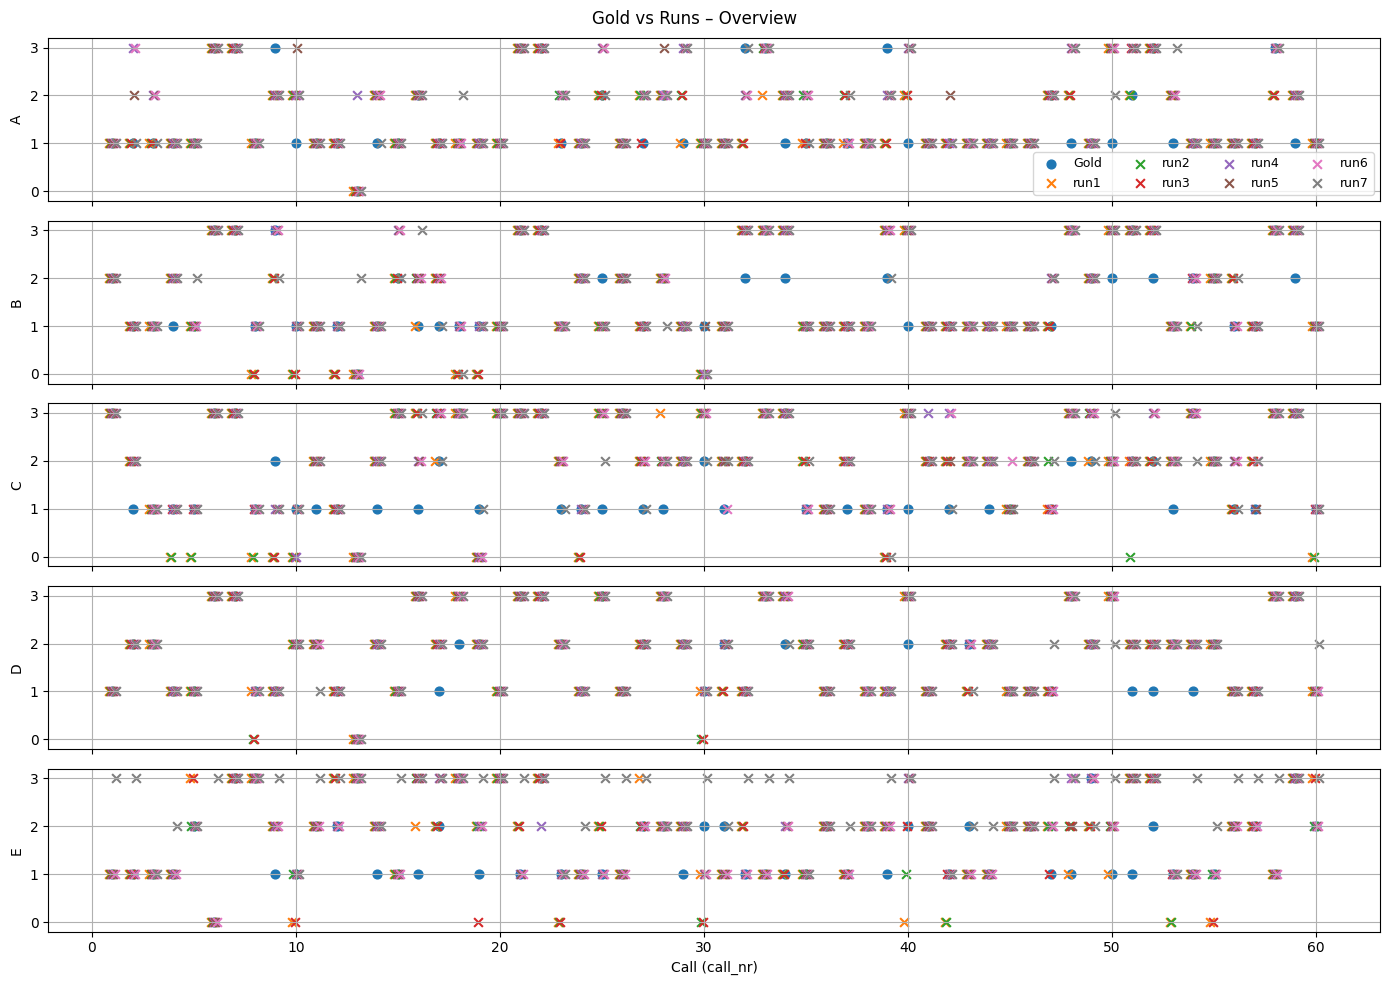

In [37]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [38]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.468000,0.28,28.08,0.641374
1,conf_error,1,B,60,0.355833,0.22,21.35,0.513009
2,conf_error,1,C,60,0.460333,0.38,27.62,0.565632
3,conf_error,1,D,60,0.296000,0.22,17.76,0.374255
4,conf_error,1,E,60,0.523333,0.45,31.40,0.607402
...,...,...,...,...,...,...,...,...
65,error,7,A,60,0.350000,0.00,21.00,0.741620
66,error,7,B,60,0.366667,0.00,22.00,0.707107
67,error,7,C,60,0.366667,0.00,22.00,0.683130
68,error,7,D,60,0.200000,0.00,12.00,0.483046


In [39]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.468000,0.355833,0.460333,0.296000,0.523333
2,0.461667,0.374500,0.461667,0.288500,0.512167
3,0.462167,0.366333,0.455000,0.299833,0.511167
4,0.488833,0.348000,0.438667,0.291500,0.450667
5,0.499833,0.349667,0.430833,0.290833,0.432667
6,0.482833,0.341833,0.448333,0.292667,0.447667
7,0.378833,0.354000,0.432000,0.274667,0.909167


In [40]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.366667,0.350000,0.533333,0.150000,0.483333
2,0.400000,0.366667,0.600000,0.183333,0.450000
3,0.366667,0.350000,0.483333,0.183333,0.450000
4,0.483333,0.250000,0.450000,0.116667,0.366667
5,0.483333,0.233333,0.400000,0.116667,0.316667
6,0.450000,0.250000,0.433333,0.116667,0.333333
7,0.350000,0.366667,0.366667,0.200000,0.983333


In [41]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.420700,126.21,2.16
1,conf_error,2,300,0.419700,125.91,1.90
2,conf_error,3,300,0.418900,125.67,1.90
3,conf_error,4,300,0.403533,121.06,1.94
4,conf_error,5,300,0.400767,120.23,1.94
5,conf_error,6,300,0.402667,120.80,1.94
6,conf_error,7,300,0.469733,140.92,1.90
7,error,1,300,0.376667,113.00,3.00
8,error,2,300,0.400000,120.00,3.00
9,error,3,300,0.366667,110.00,3.00


In [42]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,113,126.21
1,2,120,125.91
2,3,110,125.67
3,4,100,121.06
4,5,93,120.23
5,6,95,120.80
6,7,136,140.92


In [43]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.414286,174,0.463167,194.53
1,B,0.309524,130,0.355738,149.41
2,C,0.466667,196,0.446690,187.61
3,D,0.152381,64,0.290571,122.04
4,E,0.483333,203,0.540976,227.21
